
<div style="text-align:center">
<img src="img/intro.jpg">
</div>

# Introduction


In this new 2027 file, I will mix Quadratic and uncertain Operations research optimizations ( For Example, costs reduction, employees shifts assignments, vehicules 3d packings, load balancings stuffs, quadratic vehicules routing ...), Simulations (For example, Monte carlo ), Ode differential equations ( For example, tank heat surveillance), Machine learning predictive models, Maths probabilities, and maybe some supply chain metrics or others kind of maths from school books ( For example tanks and pipes pressures), applied to Factories, Mines and Agricultural examples .


<div style="text-align:center">
<img src="img/chatgemi.jpg">
</div>

Unlike my ancient files, I will focuse and analyse various real world technics, for a dedicated fictive factory for example .
I think It will be funnier to read.
Due to A.I, It's kind of faster, some kind of stupid copy pasting, but as soon as you really understand what's going on, you can replicate it in a real world process.
I have also noticed only one error in a OR generated code, so It has to be carrefully readen and analyzed. A.I provides a new faster way of learning, but It's important to being overwhelmed by the flood of information, tackle the topics point by point, and verify as much as possible, using school books, when you have time.


# <b> Summary </b>
1. <b> Factory : Simple Monte Carlo Simulation: Machine Reliability</b>
    - Abstract
    - Instance
    - Python code
2. <b> Agricultural : Simple Monte Carlo Simulation: Bad weather profit loss</b>
    - Abstract
    - Instance
    - Python code
3. <b> Mines : Optimizations and queues reduction</b>
    - Linear basic optimization with DOcplex
    - Quadratic optimization with DOcplex (various penalties)
    - Trucks and machinery queues reduction
4. <b> Agricultural : Assign 3 workers repairing 7 agricultural machines scheduling.
    - Linear MILP scheduling optimization involving workers skills


# <b> 1.  Factory : Simple Monte Carlo Simulation: Machine Reliability</b>


<div style="text-align:center">
<img src="img/olmach.jpg">
</div>

🏭 Simple Monte Carlo Simulation: Machine Reliability

Imagine that a factory has one critical machine.

We assume:
- The machine has a 95% probability of working each day.
- We want to know the probability that the machine works for 30 consecutive days without failure.
- We run 100,000 simulations.

The idea behind Monte Carlo is simple:

Simulate many random scenarios and count how many scenarios succeed.

1. Mathematical model

For each day:

$$ P(\text{machine works}) = 0.95 $$

The machine is considered reliable for the 30-day period if it works every day.

The theoretical probability is:

$$ P(\text{30 days without failure}) = 0.95^{30} $$

which is approximately:

$$ 0.95^{30} \approx 0.2146 $$

So there is about a 21.46% probability of having 30 consecutive days without a failure.






2. Python Monte Carlo simulation

In [121]:
import random

# Parameters
daily_reliability = 0.95
number_of_days = 30
number_of_simulations = 100000

success = 0

# Monte Carlo simulation
for simulation in range(number_of_simulations):

    machine_reliable = True

    for day in range(number_of_days):

        # Random number between 0 and 1
        r = random.random()

        # Machine fails if r > 0.95
        if r > daily_reliability:
            machine_reliable = False
            break

    if machine_reliable:
        success += 1

# Result
probability = success / number_of_simulations

print("Number of simulations:", number_of_simulations)
print("Scenarios without failure:", success)
print("Estimated probability:", probability * 100 , "%")

Number of simulations: 100000
Scenarios without failure: 21534
Estimated probability: 21.534 %


The simulation gives approximately:

$$ \boxed{21.45\%} $$

which is very close to the theoretical value of 21.46%.

3. Why is Monte Carlo useful in a factory?

The interesting part is that we can make the model more realistic.

For example, suppose the factory has three machines:

Machine A → reliability = 98%<br>
Machine B → reliability = 95%<br>
Machine C → reliability = 90%<br>

The factory can continue production if at least 2 out of the 3 machines are working.

We can simulate this situation:

In [122]:
import random

machine_reliabilities = [0.98, 0.95, 0.90]

number_of_simulations = 100000
factory_operational = 0

for simulation in range(number_of_simulations):

    machines_working = 0

    for reliability in machine_reliabilities:

        if random.random() < reliability:
            machines_working += 1

    # Factory operates if at least 2 machines are working
    if machines_working >= 2:
        factory_operational += 1

probability = factory_operational / number_of_simulations

print("Probability that the factory operates:", probability)

Probability that the factory operates: 0.99217


This allows us to answer a real industrial question:

"What is the probability that my factory can continue production despite machine failures?"

And we can take it one step further:

$$ \boxed{ \text{Failure} \rightarrow \text{Downtime} \rightarrow \text{Lost Production} \rightarrow \text{Financial Cost} } $$

This is where Monte Carlo simulation becomes very useful for industrial reliability and risk analysis.

# <b> 2.  Agricultural : Simple Monte Carlo Simulation: Bad weather profit loss</b>

<div style="text-align:center">
<img src="img/weather-effects-collage-concept_23-2150062062.avif">
</div>

<i>Can you provide a monte carlo agricultural bad weather simulation and profit loss ?</i>

Absolutely. A very simple and useful agricultural example is to simulate bad weather → lower crop yield → lower revenue → profit loss.

🌾 Monte Carlo: Bad Weather and Farm Profit

Suppose a farmer grows wheat on 100 hectares.

Normal conditions:

Yield = 7 tons/hectare<br>
Selling price = €200/ton<br>
Production cost = €900/hectare<br>

So under normal weather:<br>

$$ Revenue = 100 \times 7 \times 200 = €140,000 $$ $$ Cost = 100 \times 900 = €90,000 $$ $$ Profit = €50,000 $$
🌧️ Weather scenarios

We introduce three possible weather conditions:

| Weather | Probability |    Yield |
| ------- | ----------: | -------: |
| Good    |         60% | 7.5 t/ha |
| Normal  |         30% | 7.0 t/ha |
| Bad     |         10% | 4.0 t/ha |

For each Monte Carlo simulation, we randomly choose the weather.

The profit is:

Profit=Yield×Area×Price−Cost



Average profit: 50023.9 €
Minimum profit: -10000.0 €
Maximum profit: 60000.0 €
Probability of loss: 9.991 %


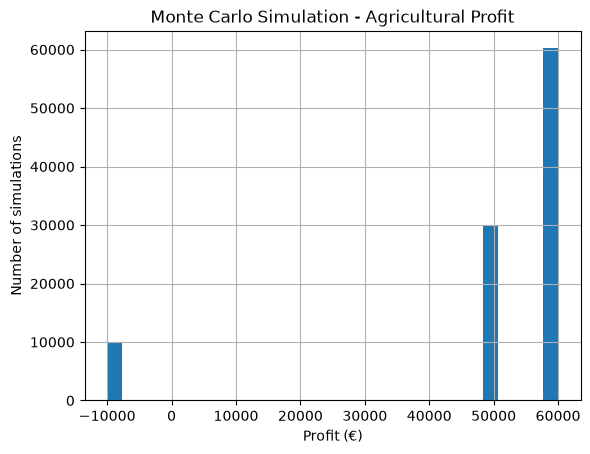

In [123]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Farm parameters
area = 100                 # hectares
price = 200                # €/ton
cost_per_hectare = 900     # €/hectare

# Weather scenarios
weather = ["Good", "Normal", "Bad"]
probabilities = [0.60, 0.30, 0.10]
yields = [7.5, 7.0, 4.0]   # tons/hectare

# Monte Carlo
number_of_simulations = 100000

profits = []
weather_results = []

for i in range(number_of_simulations):

    # Randomly select weather
    scenario = random.choices(
        weather,
        weights=probabilities
    )[0]

    # Find corresponding yield
    index = weather.index(scenario)
    crop_yield = yields[index]

    # Calculate revenue
    revenue = area * crop_yield * price

    # Calculate cost
    cost = area * cost_per_hectare

    # Calculate profit
    profit = revenue - cost

    profits.append(profit)
    weather_results.append(scenario)

# Convert to numpy array
profits = np.array(profits)

# Results
print("Average profit:", profits.mean(), "€")
print("Minimum profit:", profits.min(), "€")
print("Maximum profit:", profits.max(), "€")

# Probability of making a loss
probability_loss = np.mean(profits < 0)

print("Probability of loss:", probability_loss * 100, "%")

# Histogram
plt.hist(profits, bins=30)
plt.xlabel("Profit (€)")
plt.ylabel("Number of simulations")
plt.title("Monte Carlo Simulation - Agricultural Profit")
plt.grid()
plt.show()

📊 What will happen?

The simulation will produce three main profit levels.

Good weather:

$$ 100 \times 7.5 \times 200 - 90,000 = €60,000 $$

Normal weather:

$$ 100 \times 7.0 \times 200 - 90,000 = €50,000 $$

Bad weather:

$$ 100 \times 4.0 \times 200 - 90,000 = -€10,000 $$

So bad weather produces a €10,000 loss.

Because bad weather has a 10% probability, approximately 10% of the simulations will produce a loss.

🎯 The interesting part: Expected profit

Monte Carlo allows us to calculate:

$$ E(Profit) = 0.6(60,000) + 0.3(50,000) + 0.1(-10,000) $$ $$ E(Profit)=€50,000 $$

So the farmer can say:

"Based on my weather assumptions, my expected annual profit is approximately €50,000."

But there's an even more useful question:

"What is my probability of losing money?"

Monte Carlo gives us that directly:

$$ P(Profit < 0) $$

In this example:

$$ \boxed{P(Profit < 0) \approx 10\%} $$

This is a nice introduction to risk analysis: instead of giving only one expected profit, Monte Carlo gives a distribution of possible profits and lets us measure the probability and size of losses.

# <b>3.  Mines : Optimizations and queues reduction</b>

<div style="text-align:center">
<img src="img/mines.jpg">
</div>

## Basical linear optimisation ( Product mix )

<i>Can you provide a mining factory docplex optimization including the math model ?</i>

Absolutely. Here is a simple real-world mining factory optimization problem using IBM DOcplex, including the mathematical model, assumptions, Python code, and interpretation of the solution.

⛏️ Mining Factory Production Optimization with DOcplex
1. Real-world problem

Imagine a mining company operates a factory that processes two types of ore:

- Iron ore
- Copper ore

The factory has limited resources:

- Processing machine hours
- Electricity
- Labor hours

Each type of ore produces a different profit and consumes different amounts of resources.

The objective is:

Determine how many tons of iron and copper ore should be processed to maximize total profit while respecting factory capacity and resource limitations.

2. Example data

Suppose the factory has the following characteristics:

| Resource / Product     | Iron Ore | Copper Ore | Available |
| ---------------------- | -------: | ---------: | --------: |
| Processing hours / ton |        2 |          3 | 240 hours |
| Electricity / ton      |        4 |          2 | 240 units |
| Labor hours / ton      |        1 |          2 | 140 hours |
| Profit / ton           |      €50 |        €70 |         — |

Let:

\(x_1\) = tons of iron ore processed
\(x_2\) = tons of copper ore processed

6. Complete mathematical model

Therefore, our mining factory optimization problem is:

$$ \boxed{ \begin{aligned} \max \quad & 50x_1 + 70x_2 \\ \text{s.t.}\quad &2x_1+3x_2\leq240\\ &4x_1+2x_2\leq240\\ &x_1+2x_2\leq140\\ &x_1,x_2\geq0 \end{aligned}} $$

This is a Linear Programming (LP) model.

7. Solve it with IBM DOcplex

First install DOcplex if necessary:

In [124]:
from docplex.mp.model import Model

# -------------------------------------------------
# 1. Create the model
# -------------------------------------------------

model = Model(name="Mining_Factory_Optimization")

# -------------------------------------------------
# 2. Decision variables
# -------------------------------------------------

iron = model.continuous_var(name="iron_tons", lb=0)
copper = model.continuous_var(name="copper_tons", lb=0)

# -------------------------------------------------
# 3. Objective function
# -------------------------------------------------

model.maximize(
    50 * iron +
    70 * copper
)

# -------------------------------------------------
# 4. Constraints
# -------------------------------------------------

# Processing hours
model.add_constraint(
    2 * iron + 3 * copper <= 240,
    ctname="processing_capacity"
)

# Electricity
model.add_constraint(
    4 * iron + 2 * copper <= 240,
    ctname="electricity_capacity"
)

# Labor
model.add_constraint(
    iron + 2 * copper <= 140,
    ctname="labor_capacity"
)

# -------------------------------------------------
# 5. Display model
# -------------------------------------------------

# print(model.export_as_lp_string())

# -------------------------------------------------
# 6. Solve
# -------------------------------------------------

solution = model.solve()

# -------------------------------------------------
# 7. Display results
# -------------------------------------------------

if solution:
    print("\nOptimal solution:")
    print("---------------------------")

    print("Iron ore:", iron.solution_value, "tons")
    print("Copper ore:", copper.solution_value, "tons")

    print("Maximum profit: €",
          model.objective_value)

else:
    print("No solution found.")


Optimal solution:
---------------------------
Iron ore: 33.333333333333336 tons
Copper ore: 53.33333333333333 tons
Maximum profit: € 5400.0


# Quadratic optimization with DOcplex (various penalties)

<i>Can you take the first example, and add quadratic penalties in the objective ?</i>

Yes. We can keep the first mining factory example exactly the same, but make the objective function quadratic.

The idea is that profit is no longer perfectly linear. For example, as production increases, the factory may experience congestion, equipment wear, overtime, or processing inefficiency, causing a quadratic penalty.

⛏️ Mining Factory Quadratic Optimization

We keep:

- x_1 = tons of iron ore processed
- x_2 = tons of copper ore processed

1. Constraints

The constraints remain exactly as in the first example:

$$ 2x_1+3x_2\leq240 $$ $$ 4x_1+2x_2\leq240 $$ $$ x_1+2x_2\leq140 $$

2. Quadratic objective

Previously, we had the linear objective:

$$ \max Z=50x_1+70x_2 $$

Now let's assume that increasing production creates additional operating costs.

For example:

Iron has a quadratic processing cost of \(0.20x_1^2\)
Copper has a quadratic processing cost of \(0.30x_2^2\)

Our objective becomes:

$$ \boxed{ \max Z = 50x_1+70x_2 -0.20x_1^2 -0.30x_2^2 } $$

This is a Quadratic Programming (QP) problem.

	​
3. Complete mathematical model

We therefore have:

$$ \boxed{ \begin{aligned} \max\quad &50x_1+70x_2 -0.20x_1^2 -0.30x_2^2\\ \text{s.t.}\quad &2x_1+3x_2\leq240\\ &4x_1+2x_2\leq240\\ &x_1+2x_2\leq140\\ &x_1,x_2\geq0 \end{aligned}} $$

Notice the important difference:

Linear objective
$$ 50x_1+70x_2 $$
Quadratic objective
$$ 50x_1+70x_2 -0.20x_1^2 -0.30x_2^2 $$

The \(x^2\) terms make it quadratic.

4. DOcplex implementation

DOcplex allows us to write the quadratic objective directly in Python.

In [125]:
from docplex.mp.model import Model

# ------------------------------------------------
# 1. Create the model
# ------------------------------------------------

model = Model(name="Mining_Factory_Quadratic")

# ------------------------------------------------
# 2. Decision variables
# ------------------------------------------------

iron = model.continuous_var(
    name="iron_tons",
    lb=0
)

copper = model.continuous_var(
    name="copper_tons",
    lb=0
)

# ------------------------------------------------
# 3. Quadratic objective
# ------------------------------------------------

profit = (
    50 * iron
    + 70 * copper
    - 0.20 * iron ** 2
    - 0.30 * copper ** 2
)

model.maximize(profit)

# ------------------------------------------------
# 4. Constraints
# ------------------------------------------------

# Processing capacity
model.add_constraint(
    2 * iron + 3 * copper <= 240,
    ctname="processing_capacity"
)

# Electricity capacity
model.add_constraint(
    4 * iron + 2 * copper <= 240,
    ctname="electricity_capacity"
)

# Labor capacity
model.add_constraint(
    iron + 2 * copper <= 140,
    ctname="labor_capacity"
)

# ------------------------------------------------
# 5. Display model
# ------------------------------------------------

# print(model.export_as_lp_string())

# ------------------------------------------------
# 6. Solve
# ------------------------------------------------

solution = model.solve()

# ------------------------------------------------
# 7. Display results
# ------------------------------------------------

if solution:

    print("\nOptimal solution")
    print("---------------------------")

    print(
        "Iron ore:",
        round(iron.solution_value, 2),
        "tons"
    )

    print(
        "Copper ore:",
        round(copper.solution_value, 2),
        "tons"
    )

    print(
        "Maximum profit: €",
        round(model.objective_value, 2)
    )

else:
    print("No solution found.")


Optimal solution
---------------------------
Iron ore: 33.33 tons
Copper ore: 53.33 tons
Maximum profit: € 4324.44


5. Why do we use a quadratic objective?

Imagine the factory produces more and more ore.

At low production levels:

       Production increases
              ↓
       Profit increases

But when production becomes very high:

       More production
              ↓
       More machine wear
              ↓
       More maintenance
              ↓
       More energy inefficiency
              ↓
       Higher operating costs

Therefore, profit doesn't increase linearly forever.